In [1]:
from pathlib import Path

PROJECT_ROOT = Path("..")  # if notebook is inside notebooks/
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "figures" / "eda"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
csv_path = DATA_DIR / "tidy_prices.csv"
parquet_path = DATA_DIR / "tidy_prices.parquet"

csv_path.exists()

False

In [3]:
csv_path.exists()

False

In [4]:
from pathlib import Path

print("Current notebook working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT.resolve())

print("\nData directory:")
print(DATA_DIR.resolve())

print("\nCSV path Python is looking for:")
print(csv_path.resolve())

print("\nDoes DATA_DIR exist?")
print(DATA_DIR.exists())

print("\nFiles inside data/processed:")
if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        print(p.name)
else:
    print("DATA_DIR does not exist")

Current notebook working directory:
/Users/charan/Documents/supermarket-price-direction/notebooks

Project root:
/Users/charan/Documents/supermarket-price-direction

Data directory:
/Users/charan/Documents/supermarket-price-direction/data/processed

CSV path Python is looking for:
/Users/charan/Documents/supermarket-price-direction/data/processed/tidy_prices.csv

Does DATA_DIR exist?
True

Files inside data/processed:
product_lookup.csv
.gitkeep
supermarket_prices_tidy.csv


In [5]:
print("CSV files in project:")

for p in PROJECT_ROOT.rglob("*.csv"):
    print(p)

CSV files in project:
../results/data_audit/hazard_capture_gap_summary.csv
../results/data_audit/hazard_name_spelling_examples.csv
../results/data_audit/price_profile_by_retailer.csv
../results/data_audit/hazard_name_spelling_summary.csv
../results/data_audit/column_profile.csv
../results/data_audit/dataset_summary.csv
../results/data_audit/hazard_duplicate_key_summary.csv
../results/data_audit/data_quality_report_summary.csv
../results/data_audit/hazard_duplicate_key_examples.csv
../results/data_audit/missing_capture_dates_by_retailer.csv
../results/data_audit/unique_counts_by_retailer.csv
../results/data_audit/date_coverage_by_retailer.csv
../results/data_audit/hazard_implausible_price_summary.csv
../results/data_cleaning/duplicate_drop_log.csv
../results/data_cleaning/product_lookup.csv
../results/data_cleaning/cleaning_decision_log.csv
../results/data_cleaning/capture_gap_flag_summary.csv
../results/data_cleaning/product_name_mapping.csv
../results/data_cleaning/duplicate_before_su

In [6]:
print("Parquet files in project:")

for p in PROJECT_ROOT.rglob("*.parquet"):
    print(p)

Parquet files in project:


In [7]:
print("Files with tidy in the name:")

for p in PROJECT_ROOT.rglob("*tidy*"):
    print(p)

Files with tidy in the name:
../data/processed/supermarket_prices_tidy.csv


In [8]:
csv_path = DATA_DIR / "tidy_prices_cleaned.csv"

In [9]:
csv_path.exists()

False

In [10]:
csv_path = DATA_DIR / "tidy_prices.csv"

In [11]:
csv_path = DATA_DIR / "tidy_prices_cleaned.csv"

In [12]:
csv_path.exists()

False

In [13]:
csv_path = DATA_DIR / "supermarket_prices_tidy.csv"
parquet_path = DATA_DIR / "supermarket_prices_tidy.parquet"

print(csv_path)
print(csv_path.exists())

../data/processed/supermarket_prices_tidy.csv
True


In [14]:
import pandas as pd

sample = pd.read_csv(csv_path, nrows=5)
sample

,product_id,retailer,category,date,product_name,product_name_normalised,price,price_per_unit,unit,own_brand_flag,capture_gap_before_row,previous_capture_date,days_since_previous_capture
0,asda_000001,ASDA,drinks,2024-01-09,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.95,l,False,False,NaN,NaN
1,asda_000001,ASDA,drinks,2024-01-10,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.95,l,False,False,2024-01-09,1.0
2,asda_000001,ASDA,drinks,2024-01-11,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.95,l,False,False,2024-01-10,1.0
3,asda_000001,ASDA,drinks,2024-01-12,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.95,l,False,False,2024-01-11,1.0
4,asda_000001,ASDA,drinks,2024-01-13,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.95,l,False,False,2024-01-12,1.0


In [15]:
sample.dtypes

product_id                         str
retailer                           str
category                           str
date                               str
product_name                       str
product_name_normalised            str
price                          float64
price_per_unit                 float64
unit                               str
own_brand_flag                    bool
capture_gap_before_row            bool
previous_capture_date              str
days_since_previous_capture    float64
dtype: object

In [16]:
sample.columns.tolist()

['product_id',
 'retailer',
 'category',
 'date',
 'product_name',
 'product_name_normalised',
 'price',
 'price_per_unit',
 'unit',
 'own_brand_flag',
 'capture_gap_before_row',
 'previous_capture_date',
 'days_since_previous_capture']

In [17]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

dtype_map = {
    "retailer": "category",
    "category": "category",
    "product_id": "category",
    "unit": "category",
    "price": "float32",
    "price_per_unit": "float32",
    "capture_gap_before_row": "boolean",
    "days_since_previous_capture": "float32",
}

# Only keep dtype rules for columns that actually exist in your file
available_cols = pd.read_csv(csv_path, nrows=0).columns
dtype_map = {k: v for k, v in dtype_map.items() if k in available_cols}

date_cols = [col for col in ["date"] if col in available_cols]

chunk_size = 500_000

if not parquet_path.exists():
    writer = None

    for i, chunk in enumerate(
        pd.read_csv(
            csv_path,
            dtype=dtype_map,
            parse_dates=date_cols,
            chunksize=chunk_size,
            low_memory=False
        )
    ):
        print(f"Processing chunk {i + 1}, rows: {len(chunk):,}")

        table = pa.Table.from_pandas(chunk, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(
                parquet_path,
                table.schema,
                compression="snappy"
            )

        writer.write_table(table)

    if writer is not None:
        writer.close()

    print("Parquet conversion complete:", parquet_path)
else:
    print("Parquet file already exists. Skipping conversion.")

Processing chunk 1, rows: 500,000
Processing chunk 2, rows: 500,000
Processing chunk 3, rows: 500,000
Processing chunk 4, rows: 500,000
Processing chunk 5, rows: 500,000
Processing chunk 6, rows: 500,000
Processing chunk 7, rows: 500,000
Processing chunk 8, rows: 500,000
Processing chunk 9, rows: 500,000
Processing chunk 10, rows: 500,000
Processing chunk 11, rows: 500,000
Processing chunk 12, rows: 500,000
Processing chunk 13, rows: 500,000
Processing chunk 14, rows: 500,000
Processing chunk 15, rows: 500,000
Processing chunk 16, rows: 500,000
Processing chunk 17, rows: 500,000
Processing chunk 18, rows: 500,000
Processing chunk 19, rows: 497,591
Parquet conversion complete: ../data/processed/supermarket_prices_tidy.parquet


In [18]:
df = pd.read_parquet(parquet_path)

df.shape

(9497591, 13)

In [19]:
df.head()

,product_id,retailer,category,date,product_name,product_name_normalised,price,price_per_unit,unit,own_brand_flag,capture_gap_before_row,previous_capture_date,days_since_previous_capture
0,asda_000001,ASDA,drinks,2024-01-09,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.949997,l,False,False,NaN,NaN
1,asda_000001,ASDA,drinks,2024-01-10,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.949997,l,False,False,2024-01-09,1.0
2,asda_000001,ASDA,drinks,2024-01-11,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.949997,l,False,False,2024-01-10,1.0
3,asda_000001,ASDA,drinks,2024-01-12,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.949997,l,False,False,2024-01-11,1.0
4,asda_000001,ASDA,drinks,2024-01-13,1000 Stories Zinfandel 75cl,1000 stories zinfandel 75cl,15.0,199.949997,l,False,False,2024-01-12,1.0


In [20]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 9497591 entries, 0 to 9497590
Data columns (total 13 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   product_id                   category      
 1   retailer                     category      
 2   category                     category      
 3   date                         datetime64[us]
 4   product_name                 str           
 5   product_name_normalised      str           
 6   price                        float32       
 7   price_per_unit               float32       
 8   unit                         category      
 9   own_brand_flag               object        
 10  capture_gap_before_row       boolean       
 11  previous_capture_date        str           
 12  days_since_previous_capture  float32       
dtypes: boolean(1), category(4), datetime64[us](1), float32(3), object(1), str(3)
memory usage: 1.6 GB


In [21]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "figures" / "eda"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"

csv_path = DATA_DIR / "supermarket_prices_tidy.csv"
parquet_path = DATA_DIR / "supermarket_prices_tidy.parquet"

In [22]:
tidy_prices.csv

NameError: name 'tidy_prices' is not defined

In [23]:
tidy_prices_cleaned.csv

NameError: name 'tidy_prices_cleaned' is not defined

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "figures" / "eda"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

parquet_path = DATA_DIR / "supermarket_prices_tidy.parquet"

df = pd.read_parquet(parquet_path)

df.shape

(9497591, 13)

In [25]:
eda_df = df[
    (df["price"].notna()) &
    (df["price_per_unit"].notna()) &
    (df["price"] > 0) &
    (df["price_per_unit"] > 0)
]

eda_df.shape

(9484529, 13)

In [26]:
overall_price_summary = eda_df[["price", "price_per_unit"]].describe()

overall_price_summary

,price,price_per_unit
count,9.484529e+06,9.484529e+06
mean,5.233459e+00,4.620565e+01
std,7.458793e+00,6.520496e+02
min,1.000000e-02,1.000000e-02
25%,1.750000e+00,3.500000e+00
50%,3.000000e+00,7.710000e+00
75%,6.000000e+00,1.500000e+01
max,4.799900e+02,1.500000e+05


In [27]:
overall_price_summary.to_csv(RESULTS_DIR / "overall_price_summary.csv")

In [28]:
retailer_price_summary = (
    eda_df
    .groupby("retailer", observed=True)["price"]
    .describe()
    .sort_values("50%")
)

retailer_price_summary

,count,mean,std,min,25%,50%,75%,max
retailer,,,,,,,,
Aldi,462606.0,2.215146,2.327344,0.09,0.99,1.59,2.49,383.000000
Morrisons,1788811.0,4.894684,6.636338,0.20,1.75,2.80,5.25,300.000000
ASDA,2452831.0,5.757611,9.227874,0.05,1.75,3.00,6.50,479.989990
Sains,2595818.0,5.464970,7.145771,0.01,1.90,3.00,6.50,190.000000
Tesco,2184463.0,5.286416,6.756379,0.09,1.75,3.00,6.00,421.049988


In [29]:
retailer_price_summary.to_csv(RESULTS_DIR / "retailer_price_summary.csv")

In [30]:
retailer_ppu_summary = (
    eda_df
    .groupby("retailer", observed=True)["price_per_unit"]
    .describe()
    .sort_values("50%")
)

retailer_ppu_summary

,count,mean,std,min,25%,50%,75%,max
retailer,,,,,,,,
Aldi,462606.0,8.030313,41.385559,0.01,2.3,5.30,9.00,2343.800049
Morrisons,1788811.0,26.232908,166.398422,0.01,3.3,7.48,15.00,11225.000000
ASDA,2452831.0,74.352013,1082.117676,0.01,3.5,7.50,16.00,99778.000000
Sains,2595818.0,48.340111,608.095764,0.01,3.9,8.00,15.60,40000.000000
Tesco,2184463.0,36.504730,259.021393,0.01,3.4,8.00,16.32,150000.000000


In [31]:
retailer_ppu_summary.to_csv(RESULTS_DIR / "retailer_price_per_unit_summary.csv")

In [32]:
category_price_summary = (
    eda_df
    .groupby("category", observed=True)["price"]
    .describe()
    .sort_values("50%", ascending=False)
)

category_price_summary

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
home,1332102.0,10.000126,12.005718,0.23,3.75,6.50,12.50,479.989990
health_products,1601938.0,7.144988,7.708975,0.09,3.00,5.25,9.00,421.049988
drinks,1081463.0,7.497560,9.059874,0.10,2.15,4.29,9.00,295.000000
pets,295362.0,4.855437,5.442829,0.39,1.80,3.80,6.00,269.989990
household,534634.0,5.369101,8.138789,0.14,2.00,3.30,6.00,269.989990
baby_products,288623.0,5.093317,5.833145,0.20,1.50,3.00,6.50,140.000000
frozen,331276.0,2.873791,1.282652,0.23,2.00,2.65,3.50,25.000000
fresh_food,1334732.0,2.800020,2.544174,0.01,1.50,2.29,3.25,383.000000
free-from,348002.0,3.249754,3.604961,0.15,1.50,2.25,3.25,47.000000


In [33]:
category_price_summary.to_csv(RESULTS_DIR / "category_price_summary.csv")

In [34]:
category_ppu_summary = (
    eda_df
    .groupby("category", observed=True)["price_per_unit"]
    .describe()
    .sort_values("50%", ascending=False)
)

category_ppu_summary


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
health_products,1601938.0,188.368439,1535.142212,0.01,4.00,12.00,49.099998,110803.500000
baby_products,288623.0,19.110712,79.619789,0.01,3.49,9.50,16.900000,16666.250000
food_cupboard,2104452.0,17.571928,206.513229,0.01,5.00,9.10,15.700000,150000.000000
free-from,348002.0,16.517406,91.651451,0.01,4.42,8.90,15.330000,8130.000000
fresh_food,1334732.0,13.096589,234.629822,0.01,4.39,7.96,12.400000,21000.000000
frozen,331276.0,8.387543,24.942966,0.01,4.45,6.90,10.000000,1150.000000
drinks,1081463.0,22.645725,110.968796,0.01,2.80,6.00,17.000000,5500.000000
home,1332102.0,20.244715,106.922791,0.01,3.00,6.00,12.990000,6000.000000
pets,295362.0,20.785643,242.328247,0.01,3.33,5.25,11.100000,7835.799805


In [35]:
plt.figure(figsize=(8, 5))
eda_df["price"].hist(bins=100)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_histogram.png", dpi=300)
plt.show()|

SyntaxError: invalid syntax (3500289681.py, line 8)

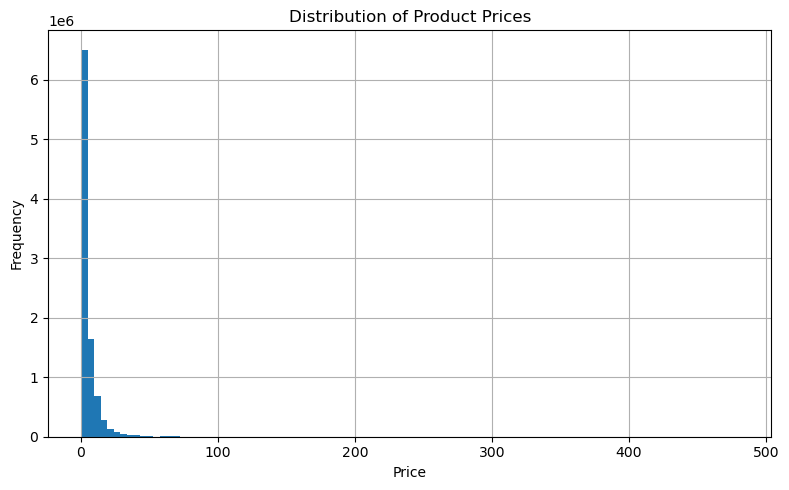

In [36]:
plt.figure(figsize=(8, 5))
eda_df["price"].hist(bins=100)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_histogram.png", dpi=300)
plt.show()

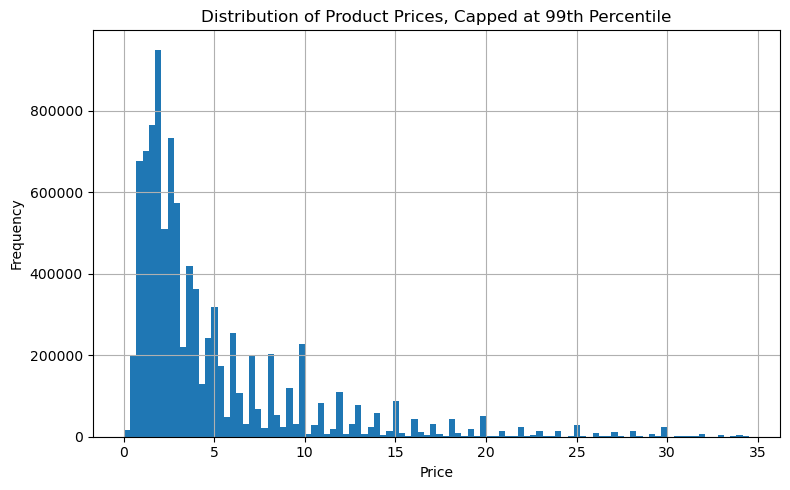

np.float64(34.5)

In [37]:
price_99 = eda_df["price"].quantile(0.99)

plt.figure(figsize=(8, 5))
eda_df.loc[eda_df["price"] <= price_99, "price"].hist(bins=100)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices, Capped at 99th Percentile")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_histogram_capped_99.png", dpi=300)
plt.show()

price_99

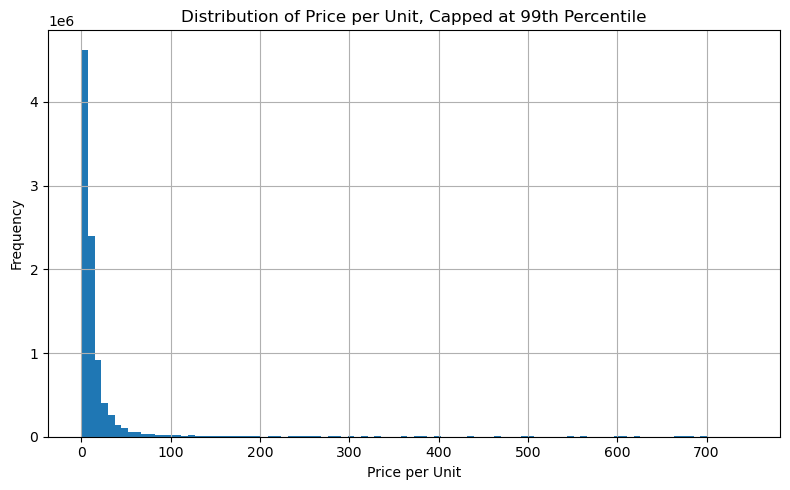

np.float64(745.0)

In [38]:
ppu_99 = eda_df["price_per_unit"].quantile(0.99)

plt.figure(figsize=(8, 5))
eda_df.loc[eda_df["price_per_unit"] <= ppu_99, "price_per_unit"].hist(bins=100)
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")
plt.title("Distribution of Price per Unit, Capped at 99th Percentile")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_per_unit_histogram_capped_99.png", dpi=300)
plt.show()

ppu_99

In [39]:
plot_df = eda_df.sample(
    n=min(500_000, len(eda_df)),
    random_state=42
)

plot_df.shape

(500000, 13)

<Figure size 1000x600 with 0 Axes>

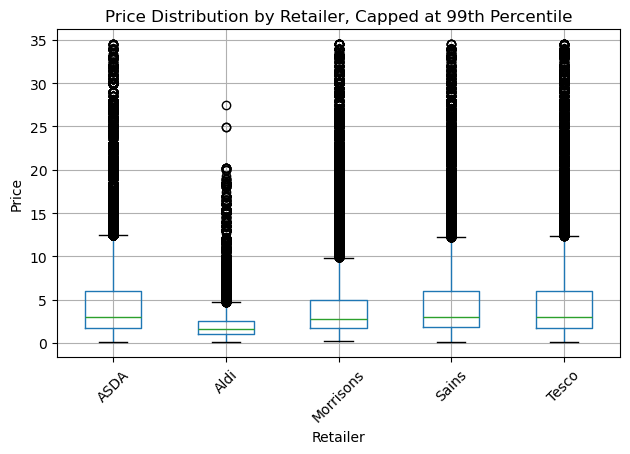

In [40]:
plot_df_price_capped = plot_df[plot_df["price"] <= price_99]

plt.figure(figsize=(10, 6))
plot_df_price_capped.boxplot(column="price", by="retailer", rot=45)
plt.title("Price Distribution by Retailer, Capped at 99th Percentile")
plt.suptitle("")
plt.xlabel("Retailer")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_boxplot_by_retailer_capped_99.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

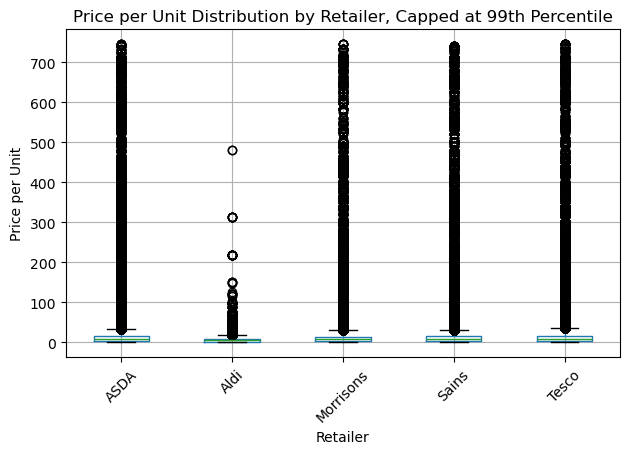

In [41]:
plot_df_ppu_capped = plot_df[plot_df["price_per_unit"] <= ppu_99]

plt.figure(figsize=(10, 6))
plot_df_ppu_capped.boxplot(column="price_per_unit", by="retailer", rot=45)
plt.title("Price per Unit Distribution by Retailer, Capped at 99th Percentile")
plt.suptitle("")
plt.xlabel("Retailer")
plt.ylabel("Price per Unit")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_per_unit_boxplot_by_retailer_capped_99.png", dpi=300)
plt.show()

In [42]:
top_categories = eda_df["category"].value_counts().head(15).index

category_plot_df = plot_df[
    plot_df["category"].isin(top_categories)
]

<Figure size 1200x600 with 0 Axes>

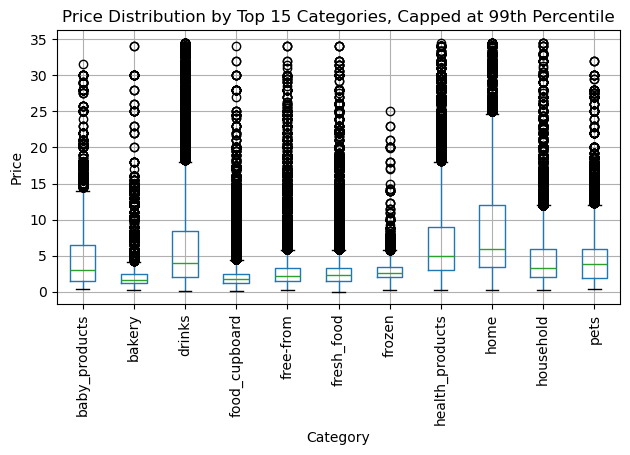

In [43]:
category_plot_df_price_capped = category_plot_df[
    category_plot_df["price"] <= price_99
]

plt.figure(figsize=(12, 6))
category_plot_df_price_capped.boxplot(column="price", by="category", rot=90)
plt.title("Price Distribution by Top 15 Categories, Capped at 99th Percentile")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_boxplot_by_category_top15_capped_99.png", dpi=300)
plt.show()

<Figure size 1200x600 with 0 Axes>

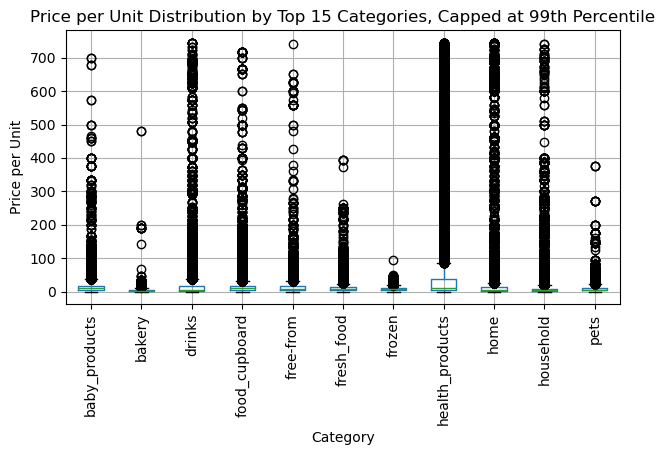

In [44]:
category_plot_df_ppu_capped = category_plot_df[
    category_plot_df["price_per_unit"] <= ppu_99
]

plt.figure(figsize=(12, 6))
category_plot_df_ppu_capped.boxplot(column="price_per_unit", by="category", rot=90)
plt.title("Price per Unit Distribution by Top 15 Categories, Capped at 99th Percentile")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Price per Unit")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_per_unit_boxplot_by_category_top15_capped_99.png", dpi=300)
plt.show()

In [45]:
print("EDA tables:")
for p in RESULTS_DIR.glob("*.csv"):
    print(p.name)

print("\nEDA figures:")
for p in FIG_DIR.glob("*.png"):
    print(p.name)

EDA tables:
overall_price_summary.csv
retailer_price_per_unit_summary.csv
retailer_price_summary.csv
category_price_summary.csv

EDA figures:
price_histogram_capped_99.png
price_boxplot_by_retailer_capped_99.png
price_per_unit_boxplot_by_retailer_capped_99.png
price_histogram.png
price_per_unit_boxplot_by_category_top15_capped_99.png
price_per_unit_histogram_capped_99.png
price_boxplot_by_category_top15_capped_99.png


In [46]:
product_id
retailer
date
price
capture_gap_before_row

NameError: name 'product_id' is not defined

In [47]:
product_id
retailer
date
price
capture_gap_before_row

NameError: name 'product_id' is not defined

In [48]:
df[[
    "product_id",
    "retailer",
    "date",
    "price",
    "capture_gap_before_row"
]].head()

,product_id,retailer,date,price,capture_gap_before_row
0,asda_000001,ASDA,2024-01-09,15.0,False
1,asda_000001,ASDA,2024-01-10,15.0,False
2,asda_000001,ASDA,2024-01-11,15.0,False
3,asda_000001,ASDA,2024-01-12,15.0,False
4,asda_000001,ASDA,2024-01-13,15.0,False


In [49]:
import numpy as np

change_df = df[[
    "product_id",
    "retailer",
    "category",
    "date",
    "price",
    "capture_gap_before_row"
]].copy()

change_df = change_df[
    change_df["price"].notna() &
    (change_df["price"] > 0)
].copy()

change_df.shape

(9497581, 6)

In [50]:
change_df = change_df.sort_values(
    ["retailer", "product_id", "date"]
).reset_index(drop=True)

change_df.head()

,product_id,retailer,category,date,price,capture_gap_before_row
0,asda_000001,ASDA,drinks,2024-01-09,15.0,False
1,asda_000001,ASDA,drinks,2024-01-10,15.0,False
2,asda_000001,ASDA,drinks,2024-01-11,15.0,False
3,asda_000001,ASDA,drinks,2024-01-12,15.0,False
4,asda_000001,ASDA,drinks,2024-01-13,15.0,False


In [51]:
group_cols = ["retailer", "product_id"]

change_df["previous_price"] = (
    change_df
    .groupby(group_cols, observed=True)["price"]
    .shift(1)
)

change_df["previous_date"] = (
    change_df
    .groupby(group_cols, observed=True)["date"]
    .shift(1)
)

change_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "previous_date",
    "previous_price",
    "capture_gap_before_row"
]].head(20)

,retailer,product_id,date,price,previous_date,previous_price,capture_gap_before_row
0,ASDA,asda_000001,2024-01-09,15.0,NaT,NaN,False
1,ASDA,asda_000001,2024-01-10,15.0,2024-01-09,15.0,False
2,ASDA,asda_000001,2024-01-11,15.0,2024-01-10,15.0,False
3,ASDA,asda_000001,2024-01-12,15.0,2024-01-11,15.0,False
4,ASDA,asda_000001,2024-01-13,15.0,2024-01-12,15.0,False
5,ASDA,asda_000001,2024-01-14,15.0,2024-01-13,15.0,False
6,ASDA,asda_000001,2024-01-15,15.0,2024-01-14,15.0,False
7,ASDA,asda_000001,2024-01-16,15.0,2024-01-15,15.0,False
8,ASDA,asda_000001,2024-01-18,15.0,2024-01-16,15.0,True
9,ASDA,asda_000001,2024-01-19,15.0,2024-01-18,15.0,False


In [52]:
change_df["valid_consecutive_comparison"] = (
    change_df["previous_price"].notna() &
    (~change_df["capture_gap_before_row"].fillna(False))
)

change_df["valid_consecutive_comparison"].value_counts(dropna=False)

valid_consecutive_comparison
True     8711346
False     786235
Name: count, dtype: Int64

In [53]:
change_df["price_changed"] = np.where(
    change_df["valid_consecutive_comparison"],
    change_df["price"].round(4) != change_df["previous_price"].round(4),
    np.nan
)

change_df["price_changed"].value_counts(dropna=False)

price_changed
0.0    8575783
NaN     786235
1.0     135563
Name: count, dtype: int64

In [54]:
overall_change_frequency = (
    change_df
    .loc[change_df["valid_consecutive_comparison"]]
    ["price_changed"]
    .agg(["count", "sum", "mean"])
)

overall_change_frequency

count    8.711346e+06
sum      1.355630e+05
mean     1.556166e-02
Name: price_changed, dtype: float64

In [55]:
overall_change_frequency.to_csv(
    RESULTS_DIR / "overall_price_change_frequency.csv"
)

In [56]:
retailer_change_frequency = (
    change_df
    .loc[change_df["valid_consecutive_comparison"]]
    .groupby("retailer", observed=True)["price_changed"]
    .agg(
        valid_comparisons="count",
        changed_count="sum",
        change_frequency="mean"
    )
    .sort_values("change_frequency", ascending=False)
)

retailer_change_frequency["stable_frequency"] = (
    1 - retailer_change_frequency["change_frequency"]
)

retailer_change_frequency

,valid_comparisons,changed_count,change_frequency,stable_frequency
retailer,,,,
Morrisons,1602161,29016.0,0.018111,0.981889
Sains,2465372,42117.0,0.017083,0.982917
ASDA,2264490,34050.0,0.015036,0.984964
Tesco,1949866,27950.0,0.014334,0.985666
Aldi,429457,2430.0,0.005658,0.994342


In [57]:
retailer_change_frequency.to_csv(
    RESULTS_DIR / "retailer_price_change_frequency.csv"
)

In [58]:
category_change_frequency = (
    change_df
    .loc[change_df["valid_consecutive_comparison"]]
    .groupby("category", observed=True)["price_changed"]
    .agg(
        valid_comparisons="count",
        changed_count="sum",
        change_frequency="mean"
    )
    .sort_values("change_frequency", ascending=False)
)

category_change_frequency["stable_frequency"] = (
    1 - category_change_frequency["change_frequency"]
)

category_change_frequency

,valid_comparisons,changed_count,change_frequency,stable_frequency
category,,,,
drinks,997054,23702.0,0.023772,0.976228
frozen,301906,6384.0,0.021146,0.978854
free-from,330143,6842.0,0.020724,0.979276
pets,272260,4816.0,0.017689,0.982311
household,502090,8746.0,0.017419,0.982581
fresh_food,1222998,21300.0,0.017416,0.982584
baby_products,264721,4458.0,0.016840,0.983160
food_cupboard,1925700,29912.0,0.015533,0.984467
health_products,1470467,19696.0,0.013394,0.986606


In [59]:
category_change_frequency.to_csv(
    RESULTS_DIR / "category_price_change_frequency.csv"
)

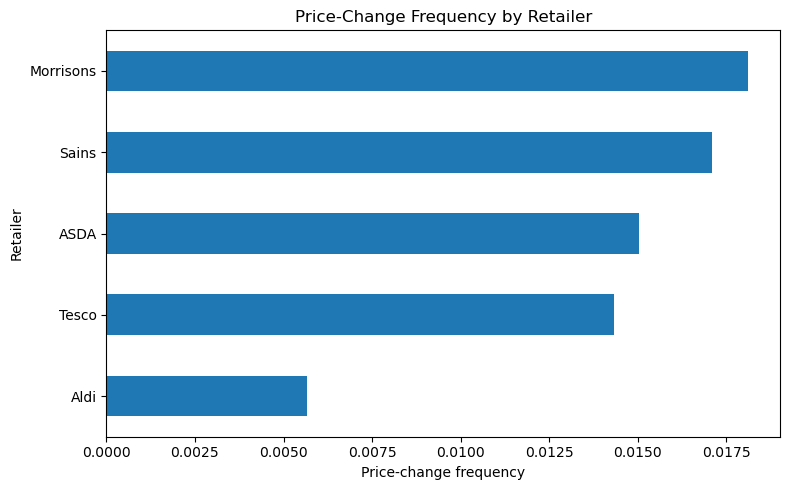

In [60]:
plt.figure(figsize=(8, 5))
retailer_change_frequency["change_frequency"].sort_values().plot(kind="barh")
plt.xlabel("Price-change frequency")
plt.ylabel("Retailer")
plt.title("Price-Change Frequency by Retailer")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_change_frequency_by_retailer.png", dpi=300)
plt.show()

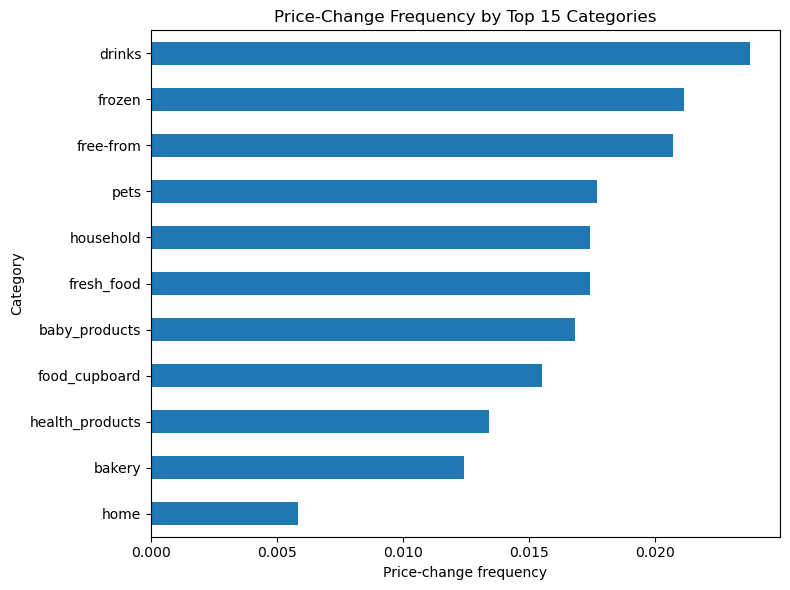

In [61]:
top_category_change_frequency = (
    category_change_frequency
    .sort_values("valid_comparisons", ascending=False)
    .head(15)
    .sort_values("change_frequency")
)

plt.figure(figsize=(8, 6))
top_category_change_frequency["change_frequency"].plot(kind="barh")
plt.xlabel("Price-change frequency")
plt.ylabel("Category")
plt.title("Price-Change Frequency by Top 15 Categories")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_change_frequency_by_category_top15.png", dpi=300)
plt.show()

In [62]:
overall_change_frequency

count    8.711346e+06
sum      1.355630e+05
mean     1.556166e-02
Name: price_changed, dtype: float64

In [63]:
retailer_change_frequency

,valid_comparisons,changed_count,change_frequency,stable_frequency
retailer,,,,
Morrisons,1602161,29016.0,0.018111,0.981889
Sains,2465372,42117.0,0.017083,0.982917
ASDA,2264490,34050.0,0.015036,0.984964
Tesco,1949866,27950.0,0.014334,0.985666
Aldi,429457,2430.0,0.005658,0.994342


In [64]:
category_change_frequency.sort_values("change_frequency", ascending=False)

,valid_comparisons,changed_count,change_frequency,stable_frequency
category,,,,
drinks,997054,23702.0,0.023772,0.976228
frozen,301906,6384.0,0.021146,0.978854
free-from,330143,6842.0,0.020724,0.979276
pets,272260,4816.0,0.017689,0.982311
household,502090,8746.0,0.017419,0.982581
fresh_food,1222998,21300.0,0.017416,0.982584
baby_products,264721,4458.0,0.016840,0.983160
food_cupboard,1925700,29912.0,0.015533,0.984467
health_products,1470467,19696.0,0.013394,0.986606


In [65]:
change_df["price_pct_change"] = np.where(
    change_df["valid_consecutive_comparison"] &
    change_df["previous_price"].notna() &
    (change_df["previous_price"] > 0),
    ((change_df["price"] - change_df["previous_price"]) / change_df["previous_price"]) * 100,
    np.nan
)

change_df[[
    "retailer",
    "product_id",
    "date",
    "price",
    "previous_price",
    "price_pct_change",
    "capture_gap_before_row",
    "valid_consecutive_comparison"
]].head(20)

,retailer,product_id,date,price,previous_price,price_pct_change,capture_gap_before_row,valid_consecutive_comparison
0,ASDA,asda_000001,2024-01-09,15.0,NaN,NaN,False,False
1,ASDA,asda_000001,2024-01-10,15.0,15.0,0.0,False,True
2,ASDA,asda_000001,2024-01-11,15.0,15.0,0.0,False,True
3,ASDA,asda_000001,2024-01-12,15.0,15.0,0.0,False,True
4,ASDA,asda_000001,2024-01-13,15.0,15.0,0.0,False,True
5,ASDA,asda_000001,2024-01-14,15.0,15.0,0.0,False,True
6,ASDA,asda_000001,2024-01-15,15.0,15.0,0.0,False,True
7,ASDA,asda_000001,2024-01-16,15.0,15.0,0.0,False,True
8,ASDA,asda_000001,2024-01-18,15.0,15.0,NaN,True,False
9,ASDA,asda_000001,2024-01-19,15.0,15.0,0.0,False,True


In [66]:
pct_change_df = change_df[
    change_df["valid_consecutive_comparison"] &
    change_df["price_pct_change"].notna()
].copy()

pct_change_df.shape

(8711346, 11)

In [67]:
pct_change_summary = pct_change_df["price_pct_change"].describe(
    percentiles=[
        0.001, 0.005, 0.01, 0.05,
        0.10, 0.25, 0.50, 0.75,
        0.90, 0.95, 0.99, 0.995, 0.999
    ]
)

pct_change_summary

count    8.711346e+06
mean     1.966915e-01
std      1.884470e+01
min     -9.971429e+01
0.1%    -4.545455e+01
0.5%    -2.000000e+01
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      0.000000e+00
95%      0.000000e+00
99%      0.000000e+00
99.5%    2.307693e+01
99.9%    8.000000e+01
max      3.490000e+04
Name: price_pct_change, dtype: float64

In [68]:
pct_change_summary.to_csv(
    RESULTS_DIR / "price_percentage_change_summary.csv"
)

In [69]:
zero_change_share = (pct_change_df["price_pct_change"] == 0).mean()

zero_change_share

np.float64(0.9844383405273995)

In [70]:
pd.Series({
    "zero_change_share": zero_change_share,
    "nonzero_change_share": 1 - zero_change_share,
    "valid_comparisons": len(pct_change_df)
}).to_csv(RESULTS_DIR / "zero_vs_nonzero_price_change_share.csv")

In [71]:
nonzero_pct_change_df = pct_change_df[
    pct_change_df["price_pct_change"] != 0
].copy()

nonzero_pct_change_df.shape

(135563, 11)

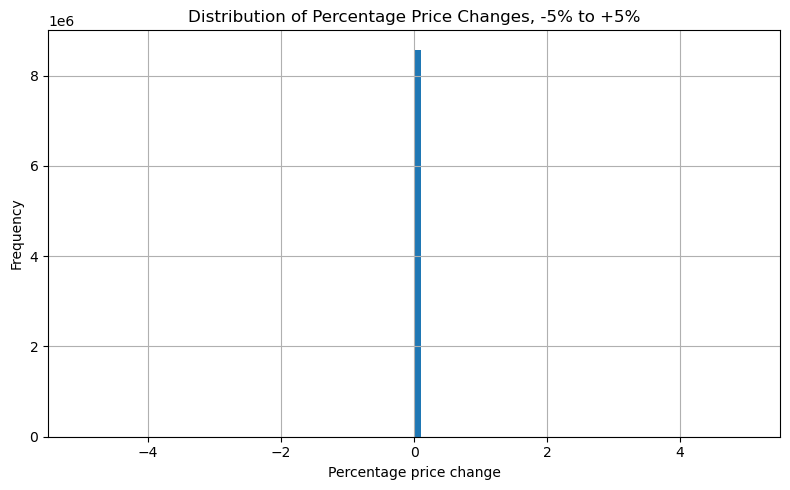

In [72]:
small_change_window = pct_change_df[
    pct_change_df["price_pct_change"].between(-5, 5)
]

plt.figure(figsize=(8, 5))
small_change_window["price_pct_change"].hist(bins=100)
plt.xlabel("Percentage price change")
plt.ylabel("Frequency")
plt.title("Distribution of Percentage Price Changes, -5% to +5%")
plt.tight_layout()
plt.savefig(FIG_DIR / "percentage_price_change_distribution_minus5_plus5.png", dpi=300)
plt.show()

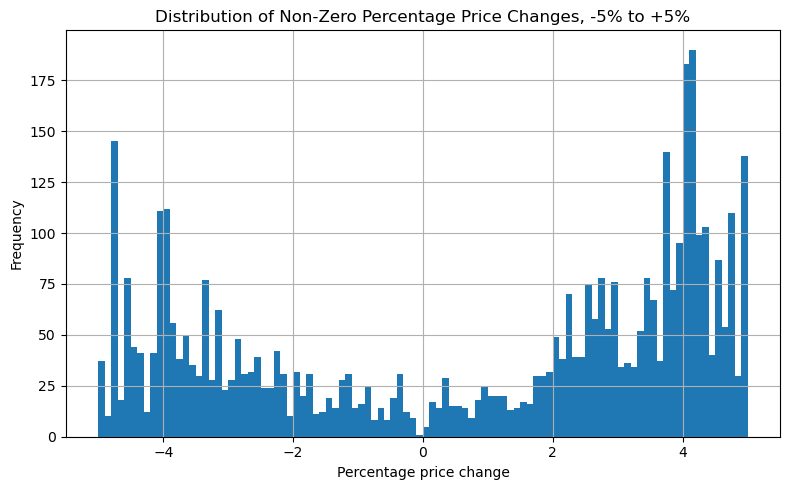

In [73]:
small_nonzero_change_window = nonzero_pct_change_df[
    nonzero_pct_change_df["price_pct_change"].between(-5, 5)
]

plt.figure(figsize=(8, 5))
small_nonzero_change_window["price_pct_change"].hist(bins=100)
plt.xlabel("Percentage price change")
plt.ylabel("Frequency")
plt.title("Distribution of Non-Zero Percentage Price Changes, -5% to +5%")
plt.tight_layout()
plt.savefig(FIG_DIR / "nonzero_percentage_price_change_distribution_minus5_plus5.png", dpi=300)
plt.show()

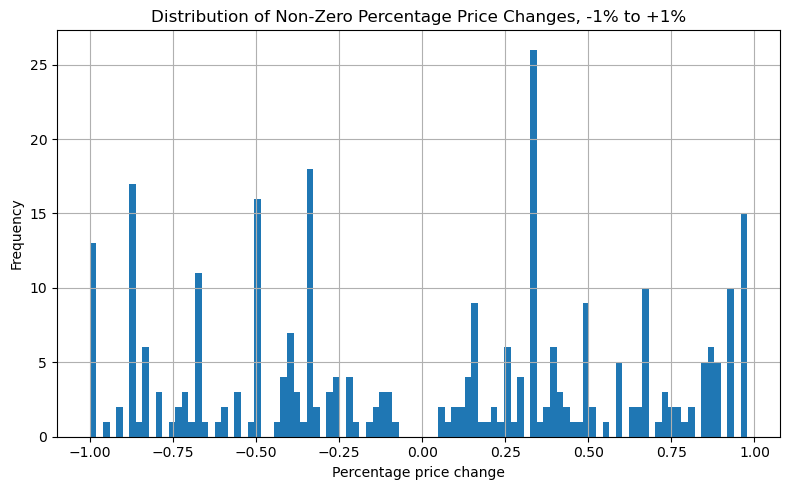

In [74]:
tiny_nonzero_change_window = nonzero_pct_change_df[
    nonzero_pct_change_df["price_pct_change"].between(-1, 1)
]

plt.figure(figsize=(8, 5))
tiny_nonzero_change_window["price_pct_change"].hist(bins=100)
plt.xlabel("Percentage price change")
plt.ylabel("Frequency")
plt.title("Distribution of Non-Zero Percentage Price Changes, -1% to +1%")
plt.tight_layout()
plt.savefig(FIG_DIR / "nonzero_percentage_price_change_distribution_minus1_plus1.png", dpi=300)
plt.show()

In [75]:
tolerances = [0.1, 0.25, 0.5, 1.0, 2.0]

tolerance_summary = []

for tol in tolerances:
    share_all = pct_change_df["price_pct_change"].between(-tol, tol).mean()
    share_nonzero = nonzero_pct_change_df["price_pct_change"].between(-tol, tol).mean()
    
    tolerance_summary.append({
        "tolerance_percent": tol,
        "share_all_valid_comparisons_inside_band": share_all,
        "share_nonzero_changes_inside_band": share_nonzero
    })

tolerance_summary = pd.DataFrame(tolerance_summary)

tolerance_summary

,tolerance_percent,share_all_valid_comparisons_inside_band,share_nonzero_changes_inside_band
0,0.10,0.984439,0.000044
1,0.25,0.984444,0.000332
2,0.50,0.984456,0.001121
3,1.00,0.984473,0.002242
4,2.00,0.984522,0.005370


In [76]:
tolerance_summary.to_csv(
    RESULTS_DIR / "stable_tolerance_band_summary.csv",
    index=False
)

In [77]:
pct_change_summary
zero_change_share
tolerance_summary

,tolerance_percent,share_all_valid_comparisons_inside_band,share_nonzero_changes_inside_band
0,0.10,0.984439,0.000044
1,0.25,0.984444,0.000332
2,0.50,0.984456,0.001121
3,1.00,0.984473,0.002242
4,2.00,0.984522,0.005370


In [78]:
from IPython.display import display

print("Percentage change summary:")
display(pct_change_summary)

print("\nZero change share:")
display(zero_change_share)

print("\nTolerance summary:")
display(tolerance_summary)

Percentage change summary:


count    8.711346e+06
mean     1.966915e-01
std      1.884470e+01
min     -9.971429e+01
0.1%    -4.545455e+01
0.5%    -2.000000e+01
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      0.000000e+00
95%      0.000000e+00
99%      0.000000e+00
99.5%    2.307693e+01
99.9%    8.000000e+01
max      3.490000e+04
Name: price_pct_change, dtype: float64


Zero change share:


np.float64(0.9844383405273995)


Tolerance summary:


,tolerance_percent,share_all_valid_comparisons_inside_band,share_nonzero_changes_inside_band
0,0.10,0.984439,0.000044
1,0.25,0.984444,0.000332
2,0.50,0.984456,0.001121
3,1.00,0.984473,0.002242
4,2.00,0.984522,0.005370


In [79]:
tolerance_summary_percent = tolerance_summary.copy()

for col in [
    "share_all_valid_comparisons_inside_band",
    "share_nonzero_changes_inside_band"
]:
    tolerance_summary_percent[col] = tolerance_summary_percent[col] * 100

tolerance_summary_percent

,tolerance_percent,share_all_valid_comparisons_inside_band,share_nonzero_changes_inside_band
0,0.10,98.443903,0.004426
1,0.25,98.444351,0.033195
2,0.50,98.445579,0.112125
3,1.00,98.447324,0.224250
4,2.00,98.452191,0.537020


In [80]:
tolerance_summary_percent = tolerance_summary.copy()

for col in [
    "share_all_valid_comparisons_inside_band",
    "share_nonzero_changes_inside_band"
]:
    tolerance_summary_percent[col] = tolerance_summary_percent[col] * 100

tolerance_summary_percent

,tolerance_percent,share_all_valid_comparisons_inside_band,share_nonzero_changes_inside_band
0,0.10,98.443903,0.004426
1,0.25,98.444351,0.033195
2,0.50,98.445579,0.112125
3,1.00,98.447324,0.224250
4,2.00,98.452191,0.537020


In [81]:
extreme_pct_changes = pct_change_df[
    pct_change_df["price_pct_change"].abs() > 100
].copy()

extreme_pct_changes.shape

(4877, 11)

In [82]:
extreme_pct_changes[[
    "retailer",
    "product_id",
    "date",
    "previous_price",
    "price",
    "price_pct_change",
    "capture_gap_before_row"
]].sort_values("price_pct_change", ascending=False).head(20)

,retailer,product_id,date,previous_price,price,price_pct_change,capture_gap_before_row
8018713,Tesco,tesco_009824,2024-04-03,0.01,3.500000,34900.000000,False
8081279,Tesco,tesco_010739,2024-04-08,0.60,100.000000,16566.666016,False
8377539,Tesco,tesco_014877,2024-04-04,1.00,111.110001,11011.000000,False
8145222,Tesco,tesco_011649,2024-03-01,1.50,150.000000,9900.000000,False
8145215,Tesco,tesco_011649,2024-02-23,1.50,150.000000,9900.000000,False
2469630,Aldi,aldi_000236,2024-04-12,4.39,383.000000,8624.374023,False
7658695,Tesco,tesco_004846,2024-02-25,0.10,8.000000,7900.000000,False
8375802,Tesco,tesco_014854,2024-04-08,1.00,66.669998,6567.000000,False
7685695,Tesco,tesco_005204,2024-04-08,1.25,83.330002,6566.400391,False
8339788,Tesco,tesco_014369,2024-04-10,0.17,10.000000,5782.353027,False


In [83]:
extreme_pct_changes.to_csv(
    RESULTS_DIR / "extreme_percentage_price_changes_over_100pct.csv",
    index=False
)

In [84]:
calendar_df = change_df[
    change_df["valid_consecutive_comparison"] &
    change_df["price_pct_change"].notna()
].copy()

calendar_df["month"] = calendar_df["date"].dt.month
calendar_df["weekofyear"] = calendar_df["date"].dt.isocalendar().week.astype("int16")
calendar_df["dayofweek"] = calendar_df["date"].dt.dayofweek

calendar_df[[
    "date",
    "month",
    "weekofyear",
    "dayofweek",
    "price_pct_change"
]].head()

,date,month,weekofyear,dayofweek,price_pct_change
1,2024-01-10,1,2,2,0.0
2,2024-01-11,1,2,3,0.0
3,2024-01-12,1,2,4,0.0
4,2024-01-13,1,2,5,0.0
5,2024-01-14,1,2,6,0.0


In [85]:
change_df.columns.tolist()

['product_id',
 'retailer',
 'category',
 'date',
 'price',
 'capture_gap_before_row',
 'previous_price',
 'previous_date',
 'valid_consecutive_comparison',
 'price_changed',
 'price_pct_change']

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

change_df = df[[
    "product_id",
    "retailer",
    "category",
    "date",
    "price",
    "own_brand_flag",
    "capture_gap_before_row"
]].copy()

change_df = change_df[
    change_df["price"].notna() &
    (change_df["price"] > 0)
].copy()

change_df = change_df.sort_values(
    ["retailer", "product_id", "date"]
).reset_index(drop=True)

group_cols = ["retailer", "product_id"]

change_df["previous_price"] = (
    change_df
    .groupby(group_cols, observed=True)["price"]
    .shift(1)
)

change_df["previous_date"] = (
    change_df
    .groupby(group_cols, observed=True)["date"]
    .shift(1)
)

change_df["valid_consecutive_comparison"] = (
    change_df["previous_price"].notna() &
    (~change_df["capture_gap_before_row"].fillna(False))
)

change_df["price_changed"] = np.where(
    change_df["valid_consecutive_comparison"],
    change_df["price"].round(4) != change_df["previous_price"].round(4),
    np.nan
)

change_df["price_pct_change"] = np.where(
    change_df["valid_consecutive_comparison"] &
    (change_df["previous_price"] > 0),
    ((change_df["price"] - change_df["previous_price"]) / change_df["previous_price"]) * 100,
    np.nan
)

change_df.columns.tolist()

['product_id',
 'retailer',
 'category',
 'date',
 'price',
 'own_brand_flag',
 'capture_gap_before_row',
 'previous_price',
 'previous_date',
 'valid_consecutive_comparison',
 'price_changed',
 'price_pct_change']

In [87]:
calendar_df = change_df[
    change_df["valid_consecutive_comparison"] &
    change_df["price_pct_change"].notna()
].copy()

calendar_df["month"] = calendar_df["date"].dt.month
calendar_df["weekofyear"] = calendar_df["date"].dt.isocalendar().week.astype("int16")
calendar_df["dayofweek"] = calendar_df["date"].dt.dayofweek

calendar_df[[
    "date",
    "month",
    "weekofyear",
    "dayofweek",
    "own_brand_flag",
    "price_pct_change"
]].head()

,date,month,weekofyear,dayofweek,own_brand_flag,price_pct_change
1,2024-01-10,1,2,2,False,0.0
2,2024-01-11,1,2,3,False,0.0
3,2024-01-12,1,2,4,False,0.0
4,2024-01-13,1,2,5,False,0.0
5,2024-01-14,1,2,6,False,0.0


In [88]:
calendar_df["date"].min(), calendar_df["date"].max()

(Timestamp('2024-01-10 00:00:00'), Timestamp('2024-04-13 00:00:00'))

In [89]:
monthly_change_summary = (
    calendar_df
    .groupby("month")["price_pct_change"]
    .agg(
        valid_comparisons="count",
        mean_pct_change="mean",
        median_pct_change="median",
        changed_share=lambda x: (x != 0).mean(),
        up_share=lambda x: (x > 0).mean(),
        down_share=lambda x: (x < 0).mean()
    )
)

monthly_change_summary

,valid_comparisons,mean_pct_change,median_pct_change,changed_share,up_share,down_share
month,,,,,,
1,2049163,0.221266,0.0,0.016686,0.008332,0.008354
2,2679350,0.166005,0.0,0.015942,0.008246,0.007696
3,2668087,0.171296,0.0,0.014935,0.007179,0.007756
4,1314746,0.272463,0.0,0.014308,0.007427,0.006881


In [90]:
monthly_change_summary.to_csv(
    RESULTS_DIR / "monthly_price_change_summary.csv"
)

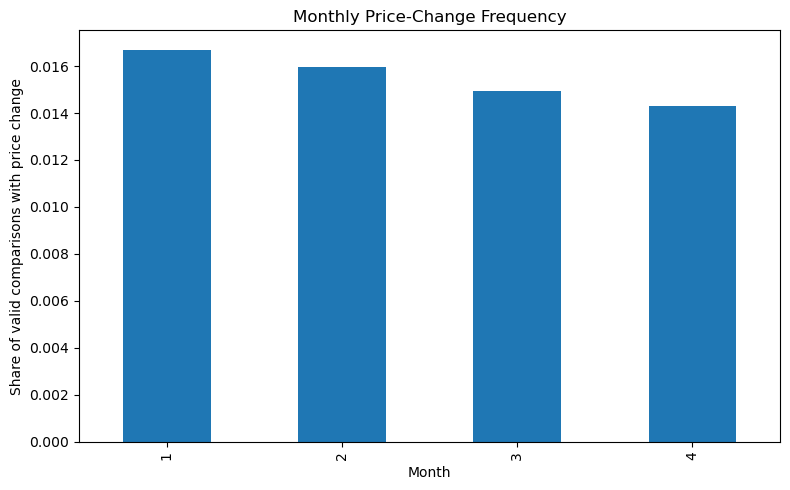

In [91]:
plt.figure(figsize=(8, 5))
monthly_change_summary["changed_share"].plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Share of valid comparisons with price change")
plt.title("Monthly Price-Change Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_price_change_frequency.png", dpi=300)
plt.show()

In [92]:
weekly_change_summary = (
    calendar_df
    .groupby("weekofyear")["price_pct_change"]
    .agg(
        valid_comparisons="count",
        mean_pct_change="mean",
        median_pct_change="median",
        changed_share=lambda x: (x != 0).mean(),
        up_share=lambda x: (x > 0).mean(),
        down_share=lambda x: (x < 0).mean()
    )
)

weekly_change_summary

,valid_comparisons,mean_pct_change,median_pct_change,changed_share,up_share,down_share
weekofyear,,,,,,
2,448828,0.276182,0.0,0.013012,0.006410,0.006602
3,642081,0.167913,0.0,0.012841,0.006040,0.006801
4,656016,0.236449,0.0,0.020528,0.010439,0.010090
5,408296,0.194509,0.0,0.024010,0.012099,0.011910
6,731678,0.097833,0.0,0.010168,0.005002,0.005166
7,721868,0.148742,0.0,0.015154,0.007827,0.007327
8,716964,0.263519,0.0,0.019769,0.010577,0.009193
9,657014,0.152249,0.0,0.012539,0.006720,0.005819
10,682501,0.138176,0.0,0.012651,0.006242,0.006409


In [93]:
weekly_change_summary.to_csv(
    RESULTS_DIR / "weekly_price_change_summary.csv"
)

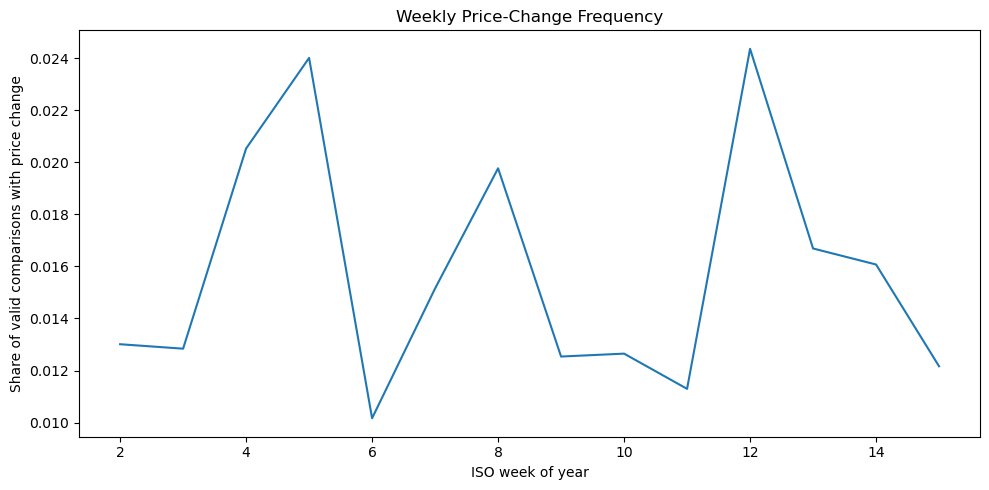

In [94]:
plt.figure(figsize=(10, 5))
weekly_change_summary["changed_share"].plot()
plt.xlabel("ISO week of year")
plt.ylabel("Share of valid comparisons with price change")
plt.title("Weekly Price-Change Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "weekly_price_change_frequency.png", dpi=300)
plt.show()

In [95]:
calendar_df["own_brand_flag"].value_counts(dropna=False)

own_brand_flag
False    6523074
True     2188259
None          13
Name: count, dtype: int64

In [96]:
own_brand_change_summary = (
    calendar_df
    .groupby("own_brand_flag", dropna=False)["price_pct_change"]
    .agg(
        valid_comparisons="count",
        mean_pct_change="mean",
        median_pct_change="median",
        changed_share=lambda x: (x != 0).mean(),
        up_share=lambda x: (x > 0).mean(),
        down_share=lambda x: (x < 0).mean()
    )
)

own_brand_change_summary

,valid_comparisons,mean_pct_change,median_pct_change,changed_share,up_share,down_share
own_brand_flag,,,,,,
False,6523074,0.233735,0.0,0.017592,0.008817,0.008775
True,2188259,0.086267,0.0,0.009509,0.004832,0.004678
NaN,13,0.000000,0.0,0.000000,0.000000,0.000000


In [97]:
own_brand_change_summary.to_csv(
    RESULTS_DIR / "own_brand_price_change_summary.csv"
)

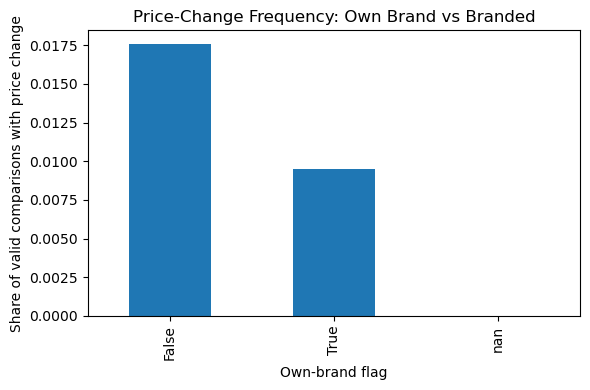

In [98]:
plt.figure(figsize=(6, 4))
own_brand_change_summary["changed_share"].plot(kind="bar")
plt.xlabel("Own-brand flag")
plt.ylabel("Share of valid comparisons with price change")
plt.title("Price-Change Frequency: Own Brand vs Branded")
plt.tight_layout()
plt.savefig(FIG_DIR / "own_brand_vs_branded_price_change_frequency.png", dpi=300)
plt.show()

In [99]:
calendar_df["christmas_period"] = (
    ((calendar_df["date"].dt.month == 12) & (calendar_df["date"].dt.day >= 15)) |
    ((calendar_df["date"].dt.month == 1) & (calendar_df["date"].dt.day <= 7))
)

christmas_change_summary = (
    calendar_df
    .groupby("christmas_period")["price_pct_change"]
    .agg(
        valid_comparisons="count",
        mean_pct_change="mean",
        median_pct_change="median",
        changed_share=lambda x: (x != 0).mean(),
        up_share=lambda x: (x > 0).mean(),
        down_share=lambda x: (x < 0).mean()
    )
)

christmas_change_summary

,valid_comparisons,mean_pct_change,median_pct_change,changed_share,up_share,down_share
christmas_period,,,,,,
False,8711346,0.196692,0.0,0.015562,0.007816,0.007746


In [100]:
christmas_change_summary.to_csv(
    RESULTS_DIR / "christmas_period_price_change_summary.csv"
)

In [101]:
print("EDA tables:")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print(p.name)

print("\nEDA figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(p.name)

EDA tables:
category_price_change_frequency.csv
category_price_summary.csv
christmas_period_price_change_summary.csv
extreme_percentage_price_changes_over_100pct.csv
monthly_price_change_summary.csv
overall_price_change_frequency.csv
overall_price_summary.csv
own_brand_price_change_summary.csv
price_percentage_change_summary.csv
retailer_price_change_frequency.csv
retailer_price_per_unit_summary.csv
retailer_price_summary.csv
stable_tolerance_band_summary.csv
weekly_price_change_summary.csv
zero_vs_nonzero_price_change_share.csv

EDA figures:
monthly_price_change_frequency.png
nonzero_percentage_price_change_distribution_minus1_plus1.png
nonzero_percentage_price_change_distribution_minus5_plus5.png
own_brand_vs_branded_price_change_frequency.png
percentage_price_change_distribution_minus5_plus5.png
price_boxplot_by_category_top15_capped_99.png
price_boxplot_by_retailer_capped_99.png
price_change_frequency_by_category_top15.png
price_change_frequency_by_retailer.png
price_histogram.png
